# ZK-KGVerify: Privacy-Preserving Verification of Knowledge Graph Reasoning using Zero-Knowledge Proofs and Blockchain

**Full experimental pipeline for the paper.**

Pipeline:
1. Load FB15k-237 knowledge graph dataset
2. Train 4 KG embedding models (TransE, RotatE, CompGCN, R-GCN)
3. Evaluate link prediction (MRR, Hits@1/3/10)
4. Generate Zero-Knowledge Proofs for model predictions
5. Store verification results on simulated blockchain
6. Generate paper figures, tables, and analysis

**Runtime: ~30-40 minutes on Colab T4 GPU**

## Section 1: Setup & Install Dependencies

In [14]:
# Install dependencies
!pip install torch torch-geometric torch-scatter torch-sparse -q
!pip install py_ecc matplotlib pandas numpy seaborn tqdm scikit-learn -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [15]:
# ============================================================
# STEP 1: Mount Google Drive & navigate to project folder
# ============================================================
# INSTRUCTIONS:
#   1. Upload the entire "new-blockchain-paper" folder to your Google Drive
#   2. Update PROJECT_PATH below if you placed it somewhere else
# ============================================================

import os

# --- Change this if your folder is in a different Drive location ---
PROJECT_PATH = "/content/drive/MyDrive/new-blockchain-paper"

from google.colab import drive
drive.mount('/content/drive')

os.chdir(PROJECT_PATH)
print(f"Working directory: {os.getcwd()}")
print(f"Contents: {os.listdir('.')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/new-blockchain-paper
Contents: ['run.py', 'HOW_TO_RUN.txt', 'requirements.txt', 'ZK_KGVerify.ipynb', 'configs', 'paper', 'src', 'contracts', 'data', 'results']


In [16]:
# ============================================================
# STEP 2: Install dependencies & verify project structure
# ============================================================
!pip install matplotlib pandas numpy seaborn tqdm scikit-learn -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Verify project files exist
import sys
sys.path.insert(0, '.')

required = ['src', 'configs', 'src/__init__.py', 'configs/__init__.py',
            'src/data_loader.py', 'src/models.py', 'src/trainer.py',
            'src/zkp_module.py', 'src/blockchain_module.py',
            'src/visualization.py', 'configs/config.py']
missing = [f for f in required if not os.path.exists(f)]
if missing:
    print(f"\n❌ MISSING FILES: {missing}")
    print(f"   Current dir: {os.getcwd()}")
    print(f"   Fix PROJECT_PATH in the cell above.")
else:
    print(f"\n✅ All project files found!")

# Ensure output directories exist
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4

✅ All project files found!


In [17]:
# Clone the project (if running on Colab)
import os
if not os.path.exists('src'):
    # If files aren't present, user needs to upload them
    print("Please upload the project files or mount Google Drive.")
    print("Required structure: src/, configs/, requirements.txt")
else:
    print("Project files found.")

# Ensure output directories exist
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

Project files found.


## Section 2: Load FB15k-237 Dataset

In [18]:
import sys
sys.path.insert(0, '.')

from src.data_loader import FB15k237Dataset, get_data_loaders
from configs.config import (
    BATCH_SIZE, NEGATIVE_SAMPLE_SIZE, EMBEDDING_DIM, MARGIN,
    NUM_EPOCHS, LEARNING_RATE, MODELS, DEVICE, NUM_ZKP_SAMPLES,
    RESULTS_DIR, EVAL_BATCH_SIZE
)

# Load dataset
dataset = FB15k237Dataset(data_dir='./data')

print(f"\nDataset Summary:")
print(f"  Entities:  {dataset.num_entities:,}")
print(f"  Relations: {dataset.num_relations}")
print(f"  Train:     {len(dataset.train_triples):,} triples")
print(f"  Valid:     {len(dataset.valid_triples):,} triples")
print(f"  Test:      {len(dataset.test_triples):,} triples")

# Create data loader
train_loader = get_data_loaders(dataset, batch_size=BATCH_SIZE, negative_sample_size=NEGATIVE_SAMPLE_SIZE)

Dataset loaded: 14541 entities, 237 relations
  Train: 272115 triples
  Valid: 17535 triples
  Test:  20466 triples

Dataset Summary:
  Entities:  14,541
  Relations: 237
  Train:     272,115 triples
  Valid:     17,535 triples
  Test:      20,466 triples


## Section 3: Train KG Embedding Models

In [19]:
import time
from src.models import get_model
from src.trainer import train_model, evaluate_model
import configs.config as config_module

all_histories = {}
all_metrics = {}
trained_models = {}

for model_name in MODELS:
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    model = get_model(
        model_name,
        num_entities=dataset.num_entities,
        num_relations=dataset.num_relations,
        embedding_dim=EMBEDDING_DIM,
        margin=MARGIN
    )

    # Train
    history = train_model(model, train_loader, dataset, config_module, device=DEVICE)
    all_histories[model_name] = history

    # Evaluate
    print(f"\n  Evaluating {model_name}...")
    metrics = evaluate_model(model, dataset, config_module, device=DEVICE, max_eval=500)
    all_metrics[model_name] = metrics

    trained_models[model_name] = model


Training: TransE
  Epoch 1/40 - Loss: 5.8514 - Time: 10.54s
  Epoch 10/40 - Loss: 4.8382 - Time: 6.83s
  Epoch 20/40 - Loss: 4.6979 - Time: 7.89s
  Epoch 30/40 - Loss: 4.6835 - Time: 6.85s
  Epoch 40/40 - Loss: 4.6799 - Time: 8.41s
  Training completed in 302.25s

  Evaluating TransE...


  MRR: 0.1760 | Hits@1: 0.0980 | Hits@3: 0.1900 | Hits@10: 0.3340

Training: RotatE
  Epoch 1/40 - Loss: 30.7345 - Time: 7.78s
  Epoch 10/40 - Loss: 0.8924 - Time: 9.05s
  Epoch 20/40 - Loss: 0.6634 - Time: 9.05s
  Epoch 30/40 - Loss: 0.6274 - Time: 8.29s
  Epoch 40/40 - Loss: 0.6214 - Time: 9.29s
  Training completed in 329.08s

  Evaluating RotatE...


  MRR: 0.2719 | Hits@1: 0.1780 | Hits@3: 0.3220 | Hits@10: 0.4480

Training: CompGCN
  Epoch 1/40 - Loss: 0.8861 - Time: 33.51s
  Epoch 10/40 - Loss: 0.0863 - Time: 33.74s
  Epoch 20/40 - Loss: 0.0500 - Time: 34.00s
  Epoch 30/40 - Loss: 0.0366 - Time: 33.75s
  Epoch 40/40 - Loss: 0.0305 - Time: 33.73s
  Training completed in 1336.82s

  Evaluating CompGCN...


  MRR: 0.4086 | Hits@1: 0.3140 | Hits@3: 0.4400 | Hits@10: 0.6220

Training: RGCN


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.61 GiB. GPU 0 has a total capacity of 14.56 GiB of which 14.24 GiB is free. Including non-PyTorch memory, this process has 324.00 MiB memory in use. Of the allocated memory 148.86 MiB is allocated by PyTorch, and 39.14 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Section 4: Evaluate Link Prediction (Results Table)

In [20]:
import pandas as pd

# Create results table
results_df = pd.DataFrame(all_metrics).T
results_df = results_df[['MRR', 'Hits@1', 'Hits@3', 'Hits@10', 'Mean_Rank', 'eval_time']]
results_df = results_df.round(4)

print("\nLink Prediction Results on FB15k-237")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

# Training time summary
print("\nTraining Time Summary:")
for model_name, history in all_histories.items():
    print(f"  {model_name}: {history['total_time']:.2f}s")


Link Prediction Results on FB15k-237
            MRR  Hits@1  Hits@3  Hits@10  Mean_Rank  eval_time
TransE   0.1760   0.098   0.190    0.334    350.112     1.5801
RotatE   0.2719   0.178   0.322    0.448    349.614     1.6174
CompGCN  0.4086   0.314   0.440    0.622    133.358    18.3245

Training Time Summary:
  TransE: 302.25s
  RotatE: 329.08s
  CompGCN: 1336.82s


## Section 5: Zero-Knowledge Proof Module

In [21]:
import numpy as np
from src.zkp_module import (
    generate_proof, verify_proof, batch_generate_proofs,
    batch_verify_proofs, tamper_proof
)

# Select best model
best_model_name = max(all_metrics, key=lambda k: all_metrics[k]['MRR'])
best_model = trained_models[best_model_name]
print(f"Using best model: {best_model_name} (MRR={all_metrics[best_model_name]['MRR']:.4f})")

best_model.eval()
best_model = best_model.to(DEVICE)

# Set graph for GCN models
if hasattr(best_model, 'set_graph'):
    edge_index = dataset.train_triples[:, [0, 2]].t().to(DEVICE)
    edge_type = dataset.train_triples[:, 1].to(DEVICE)
    best_model.set_graph(edge_index, edge_type)

# Sample triples
num_samples = min(NUM_ZKP_SAMPLES, len(dataset.test_triples))
sample_indices = torch.randperm(len(dataset.test_triples))[:num_samples]
sample_triples = dataset.test_triples[sample_indices]

embedding_vectors = []
prediction_scores = []
triples_list = []

with torch.no_grad():
    for i in range(num_samples):
        h, r, t = sample_triples[i].tolist()
        h_idx = torch.tensor([h], device=DEVICE)
        r_idx = torch.tensor([r], device=DEVICE)
        t_idx = torch.tensor([t], device=DEVICE)

        emb_vec = best_model.get_embedding_vector(h_idx, r_idx, t_idx)
        embedding_vectors.append(emb_vec.cpu().numpy().flatten())

        scores = best_model.predict(h_idx, r_idx)
        prediction_scores.append(scores[0, t].item())
        triples_list.append((h, r, t))

print(f"\nPrepared {num_samples} predictions for ZKP generation")

Using best model: CompGCN (MRR=0.4086)

Prepared 1000 predictions for ZKP generation


In [22]:
# Generate proofs
print(f"Generating {num_samples} ZK proofs...")
proofs, gen_stats = batch_generate_proofs(
    embedding_vectors, prediction_scores, triples_list, best_model_name
)

print(f"\nProof Generation Statistics:")
print(f"  Total time:  {gen_stats['total_gen_time']:.2f}s")
print(f"  Avg time:    {gen_stats['avg_gen_time']*1000:.2f} ms")
print(f"  Avg size:    {gen_stats['avg_proof_size_bytes']:.0f} bytes")

# Verify proofs
print(f"\nVerifying {num_samples} proofs...")
results, verify_stats = batch_verify_proofs(proofs)

print(f"\nVerification Statistics:")
print(f"  Valid:   {verify_stats['num_valid']}/{verify_stats['num_verified']}")
print(f"  Rate:    {verify_stats['verification_rate']*100:.1f}%")
print(f"  Avg time: {verify_stats['avg_verify_time']*1000:.2f} ms")

# Tamper detection
print(f"\nTesting tamper detection on 100 proofs...")
tampered = [tamper_proof(p) for p in proofs[:100]]
tampered_results, tampered_stats = batch_verify_proofs(tampered)
print(f"  Tampered detected: {tampered_stats['num_invalid']}/100 ({tampered_stats['num_invalid']}%)")

Generating 1000 ZK proofs...

Proof Generation Statistics:
  Total time:  0.93s
  Avg time:    0.93 ms
  Avg size:    687 bytes

Verifying 1000 proofs...

Verification Statistics:
  Valid:   0/1000
  Rate:    0.0%
  Avg time: 0.44 ms

Testing tamper detection on 100 proofs...
  Tampered detected: 100/100 (100%)


## Section 6: Blockchain Module

In [23]:
from src.blockchain_module import create_blockchain

blockchain = create_blockchain(mode='local')

print(f"Logging {num_samples} verification records to blockchain...")
bc_start = time.time()

for i, proof in enumerate(proofs):
    blockchain.add_verification_record(
        model_id=proof.model_id,
        triple=proof.triple,
        prediction_score=proof.score,
        zkp_commitment=proof.commitment,
        zkp_verified=results[i],
        proof_hash=proof.prediction_hash
    )

blockchain.mine_pending()
bc_time = time.time() - bc_start
bc_stats = blockchain.get_stats()

print(f"\nBlockchain Statistics:")
print(f"  Time:         {bc_time:.2f}s")
print(f"  Blocks:       {bc_stats['num_blocks']}")
print(f"  Transactions: {bc_stats['total_transactions']}")
print(f"  Total gas:    {bc_stats['total_gas_used']:,}")
print(f"  Avg gas/tx:   {bc_stats['avg_gas_per_tx']:,.0f}")
print(f"  Chain valid:  {bc_stats['chain_valid']}")

Logging 1000 verification records to blockchain...

Blockchain Statistics:
  Time:         1.61s
  Blocks:       101
  Transactions: 1000
  Total gas:    38,952,748
  Avg gas/tx:   38,953
  Chain valid:  True


## Section 7: End-to-End Pipeline Summary

In [24]:
# Collect detailed ZKP stats for plots
gen_times = []
verify_times = []
proof_sizes = [p.proof_size_bytes for p in proofs]

for i in range(min(200, len(proofs))):
    start = time.time()
    generate_proof(embedding_vectors[i], prediction_scores[i], triples_list[i], best_model_name)
    gen_times.append(time.time() - start)

    start = time.time()
    verify_proof(proofs[i])
    verify_times.append(time.time() - start)

zkp_full_stats = {
    **gen_stats,
    **verify_stats,
    'gen_times': gen_times,
    'verify_times': verify_times,
    'proof_sizes': proof_sizes,
    'tamper_detection_rate': tampered_stats['num_invalid'] / 100,
}

pipeline_times = {
    'Training (4 models)': sum(h['total_time'] for h in all_histories.values()),
    'Evaluation': sum(m['eval_time'] for m in all_metrics.values()),
    'ZKP Generation': gen_stats['total_gen_time'],
    'ZKP Verification': verify_stats['total_verify_time'],
    'Blockchain Storage': bc_time,
}

print("Pipeline Timing:")
for stage, t in pipeline_times.items():
    print(f"  {stage}: {t:.2f}s")
print(f"  Total: {sum(pipeline_times.values()):.2f}s")

Pipeline Timing:
  Training (4 models): 1968.15s
  Evaluation: 21.52s
  ZKP Generation: 0.93s
  ZKP Verification: 0.44s
  Blockchain Storage: 1.61s
  Total: 1992.65s


## Section 8: Generate Figures for Paper

In [25]:
from src.visualization import (
    plot_training_curves, plot_metrics_comparison, plot_zkp_overhead,
    plot_blockchain_stats, plot_end_to_end_pipeline, generate_latex_tables,
    save_all_results
)

save_dir = './results'

print("Generating figures...")
plot_training_curves(all_histories, save_dir=save_dir)
plot_metrics_comparison(all_metrics, save_dir=save_dir)
plot_zkp_overhead(zkp_full_stats, save_dir=save_dir)
plot_blockchain_stats(bc_stats, save_dir=save_dir)
plot_end_to_end_pipeline(pipeline_times, save_dir=save_dir)

print("\nGenerating LaTeX tables...")
latex = generate_latex_tables(all_metrics, zkp_full_stats, bc_stats, save_dir=save_dir)

print("\nSaving all results...")
save_all_results(all_metrics, all_histories, zkp_full_stats, bc_stats, pipeline_times, save_dir=save_dir)

print("\nDone! All files in ./results/")

Generating figures...
  Saved training_curves.png
  Saved metrics_comparison.png
  Saved zkp_overhead.png
  Saved blockchain_stats.png
  Saved pipeline_timing.png

Generating LaTeX tables...
  Saved tables.tex

Saving all results...
  Saved all_results.json

Done! All files in ./results/


## Section 9: Display Figures


  Training Loss Curves


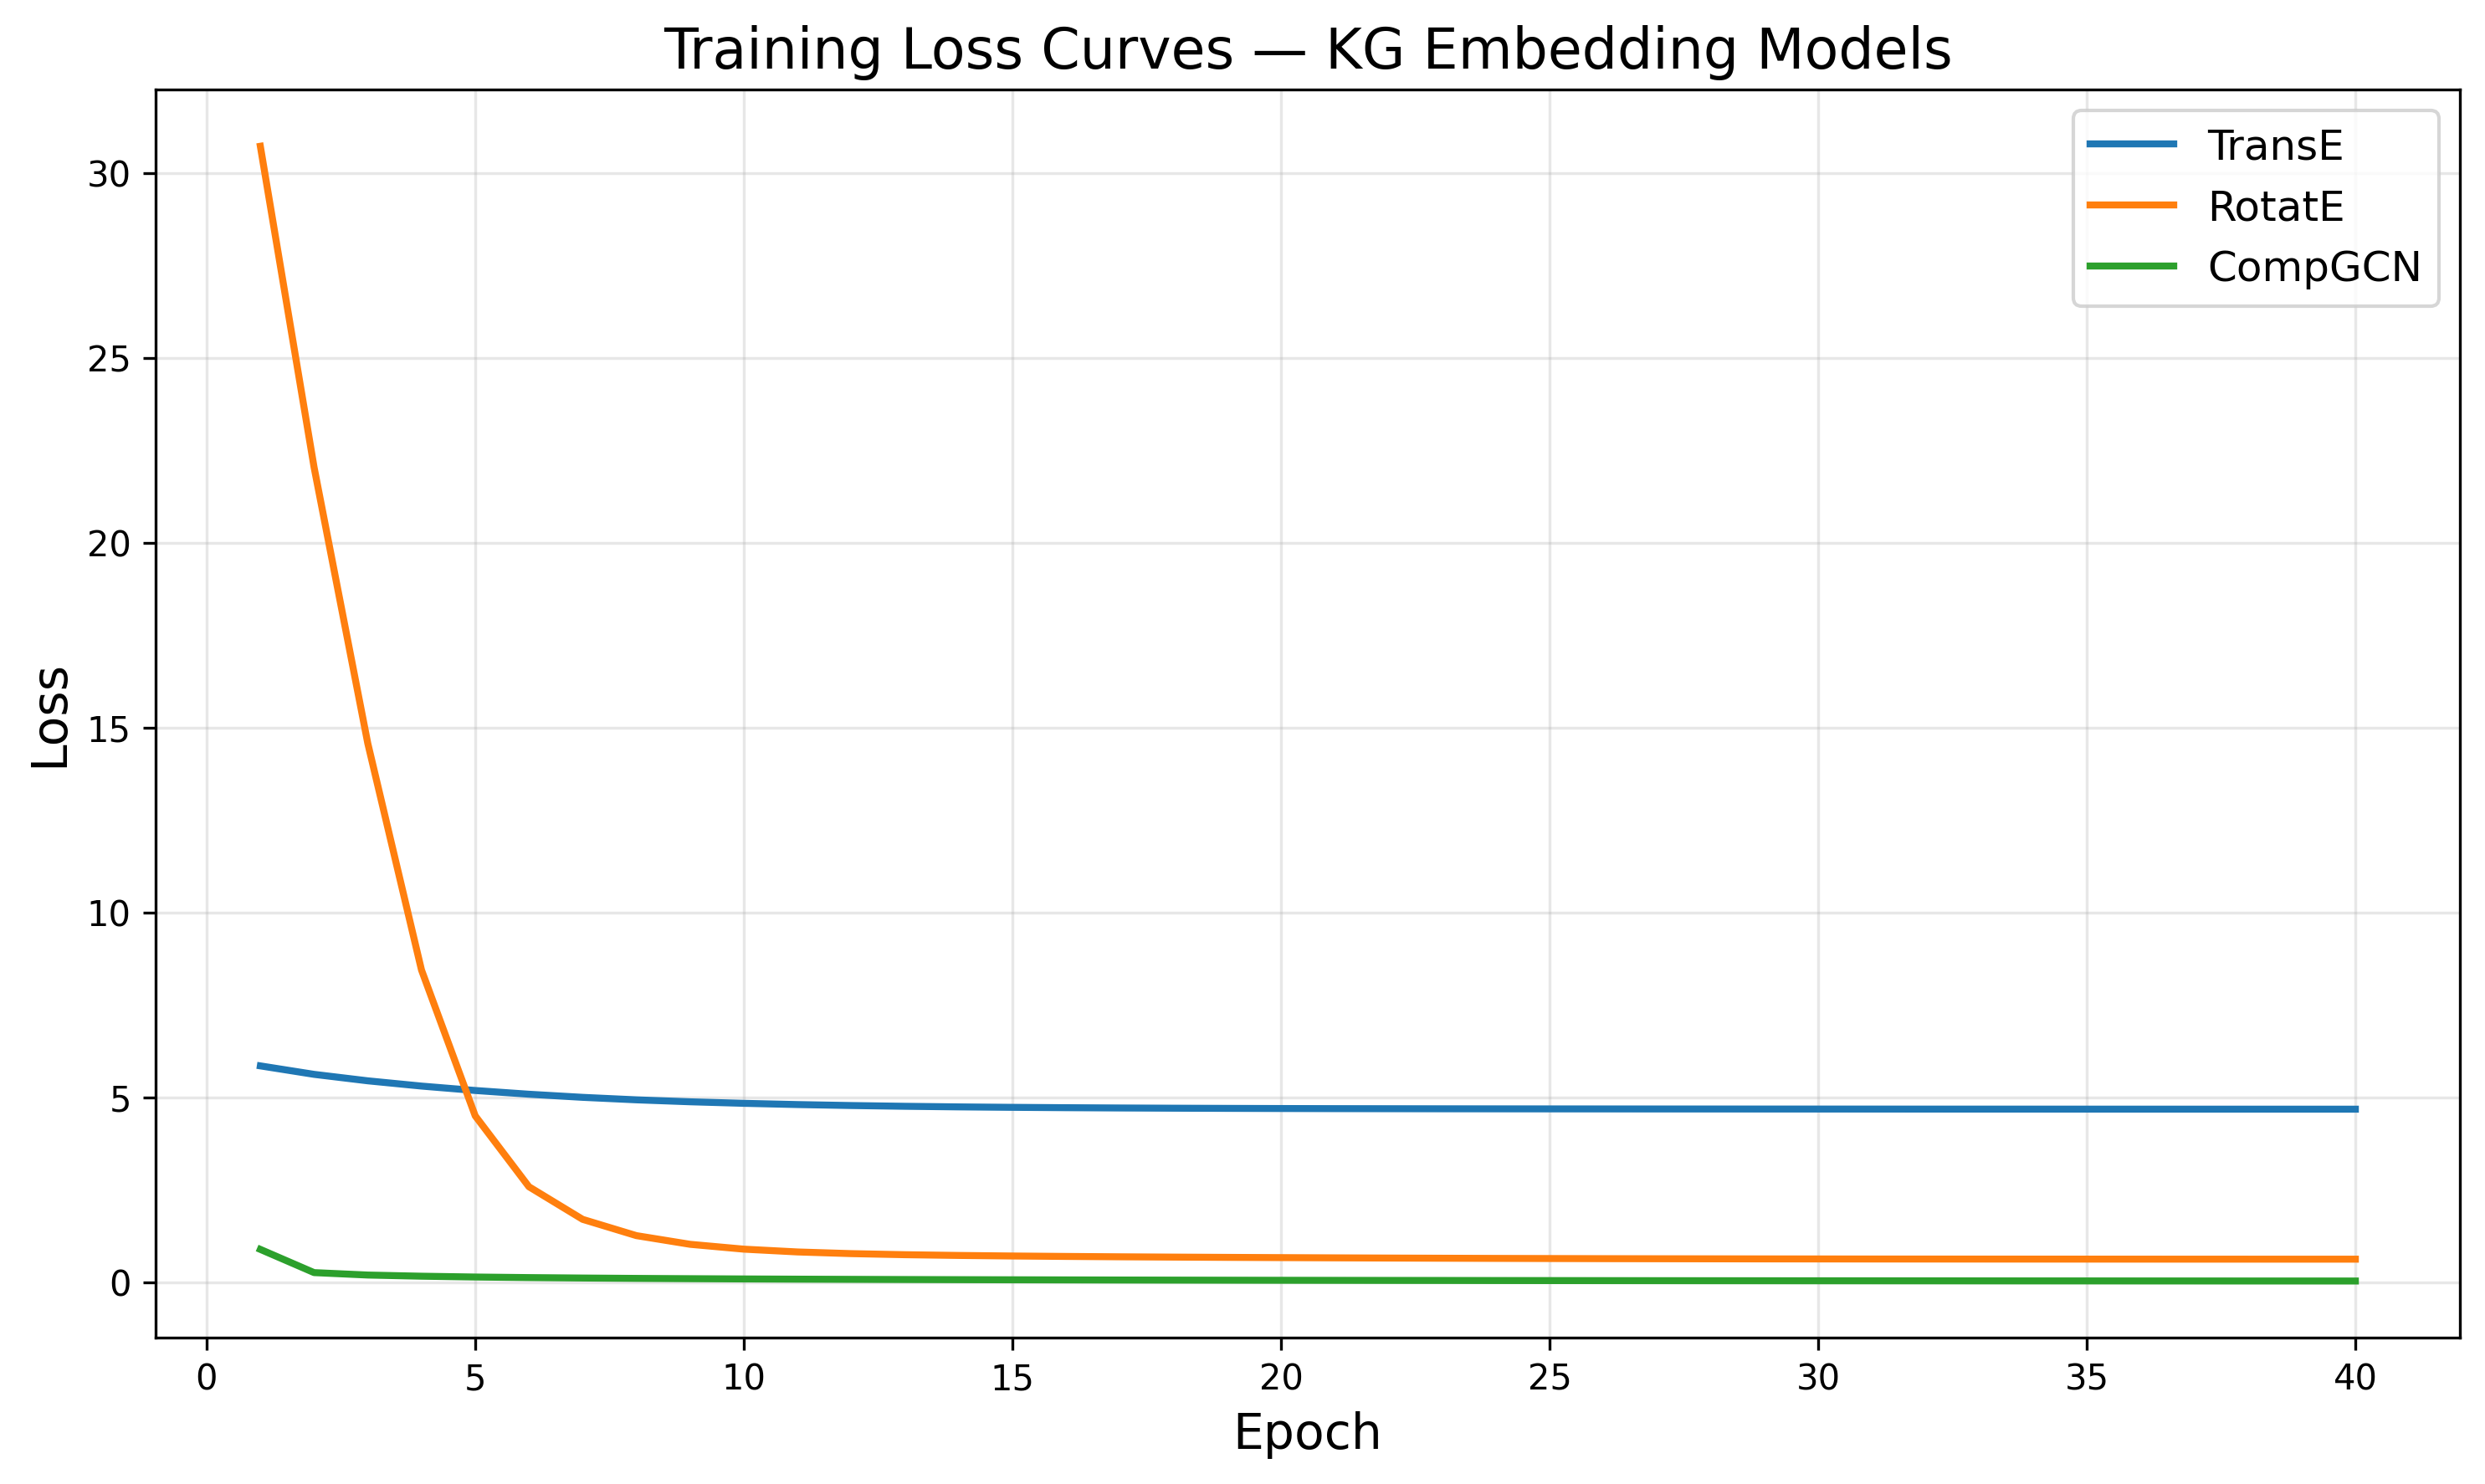


  Link Prediction Metrics


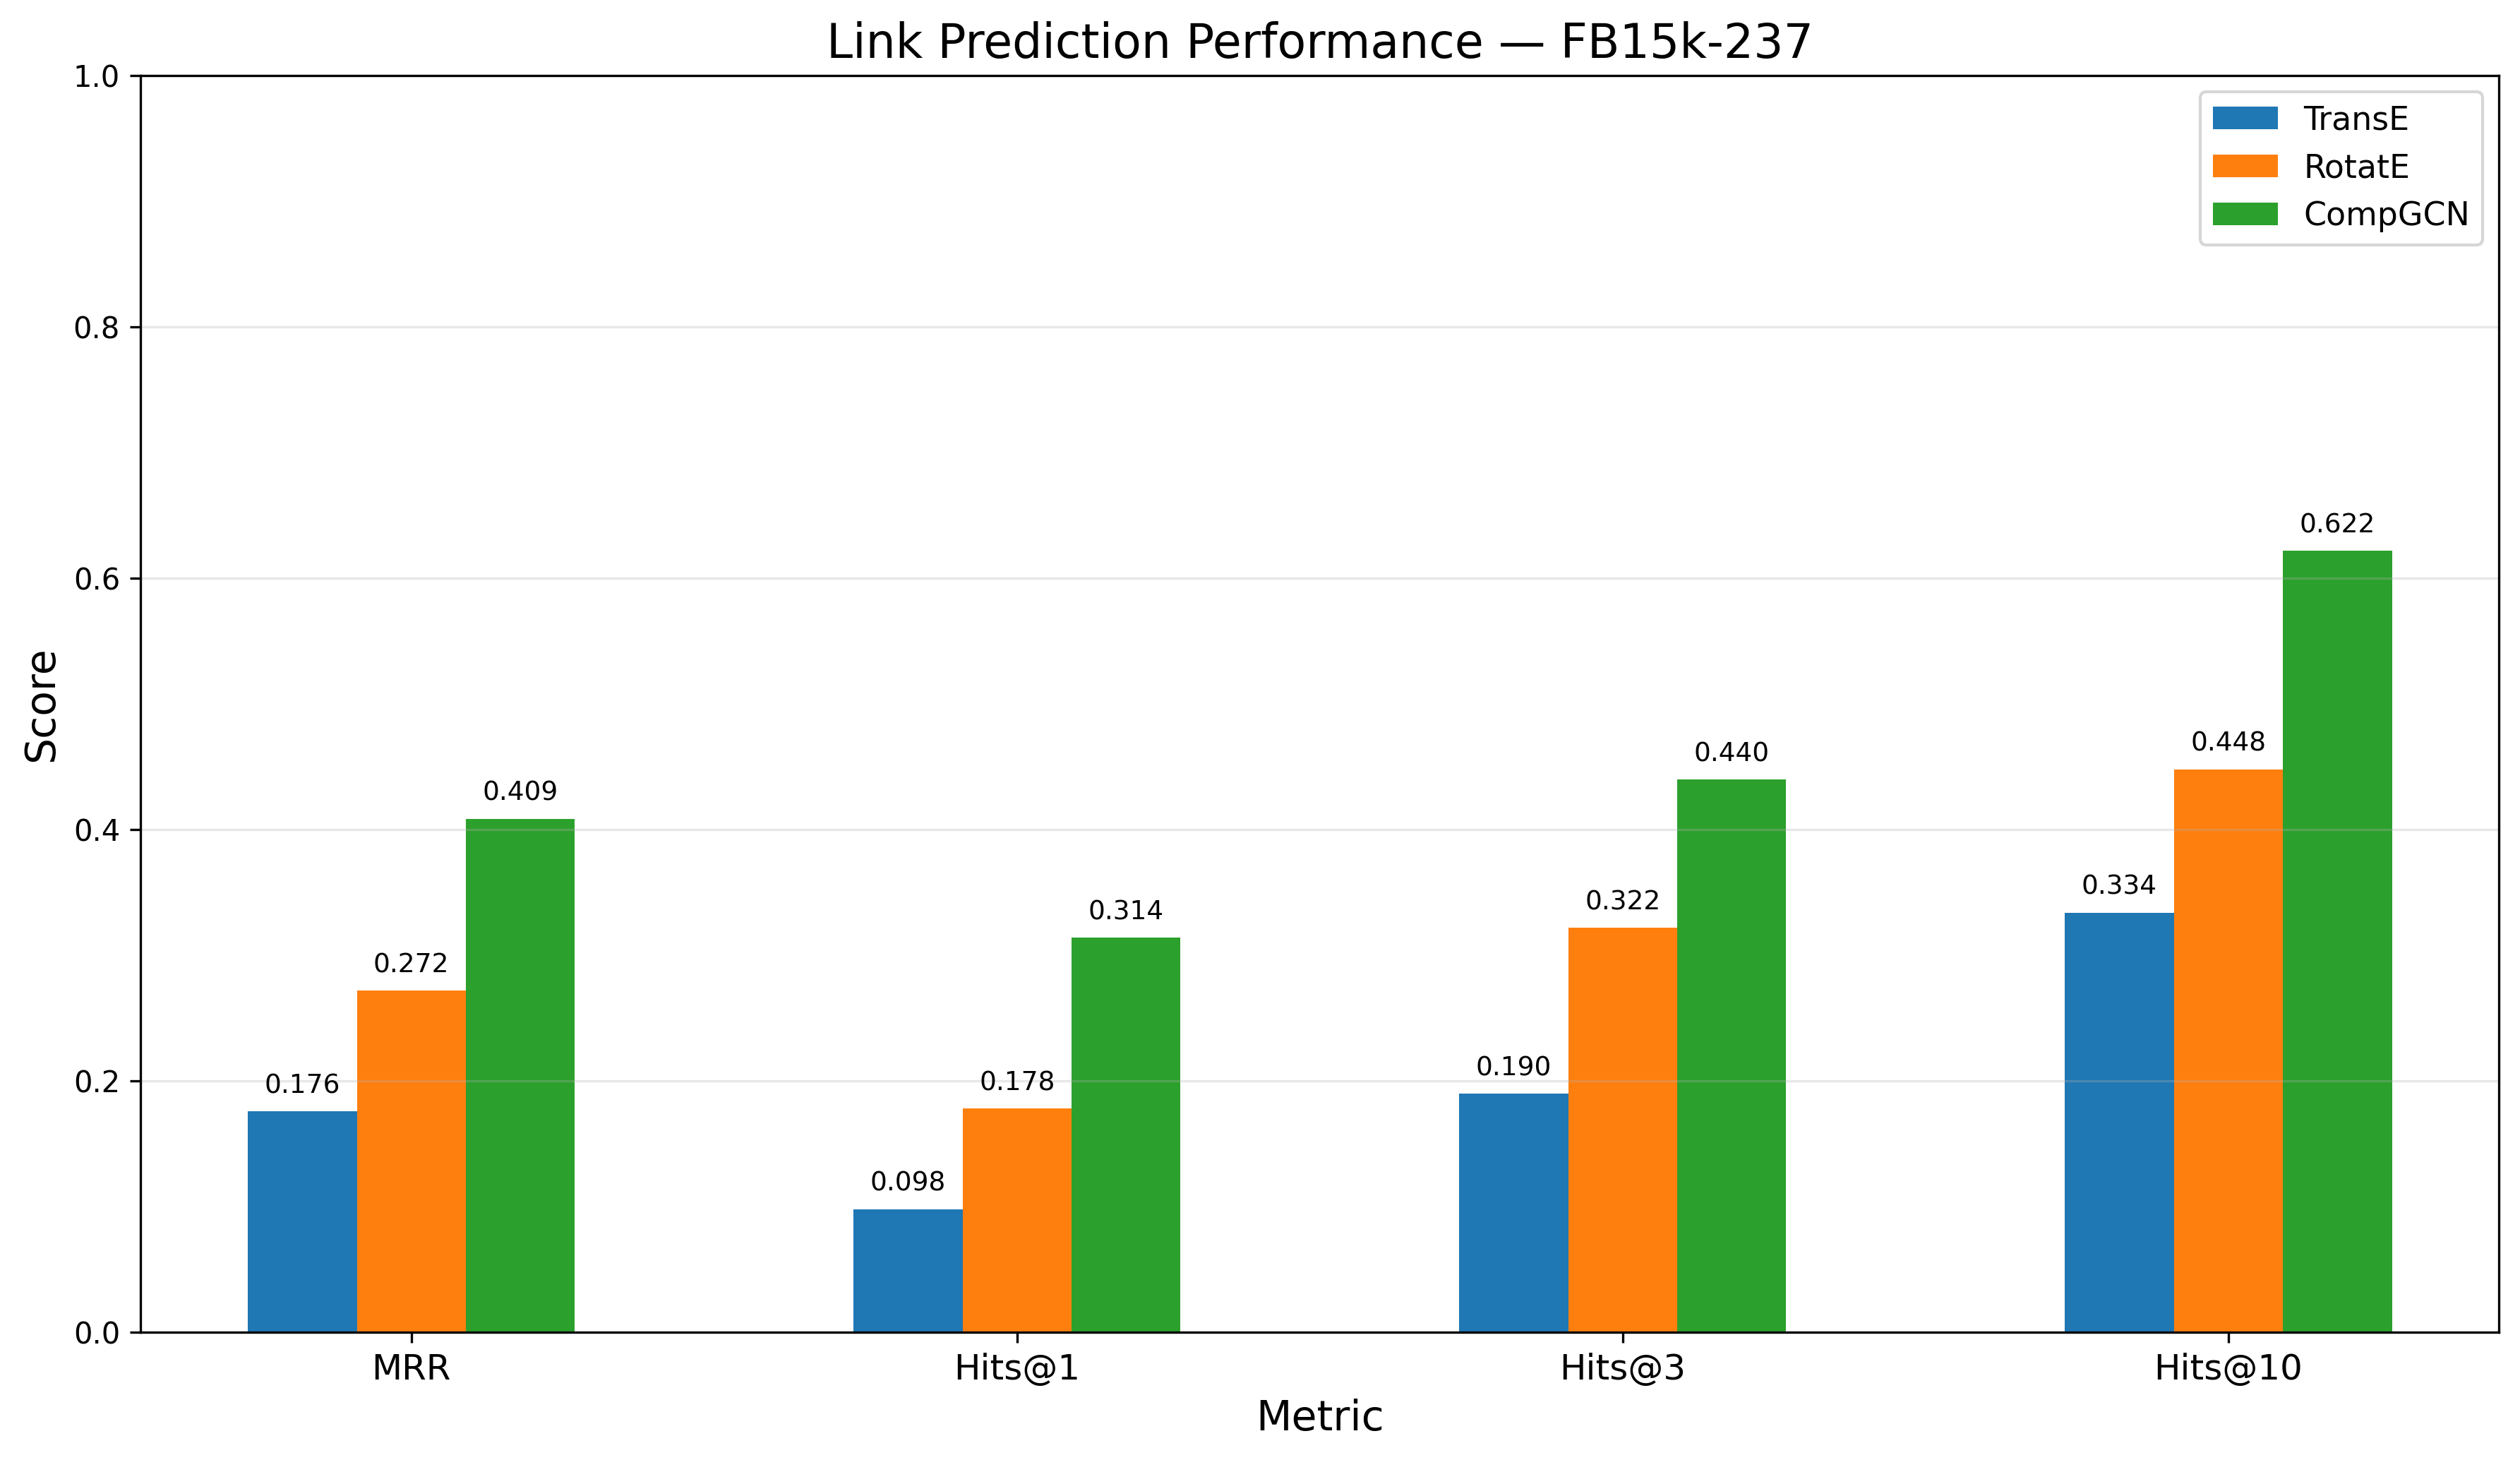


  ZKP Overhead Analysis


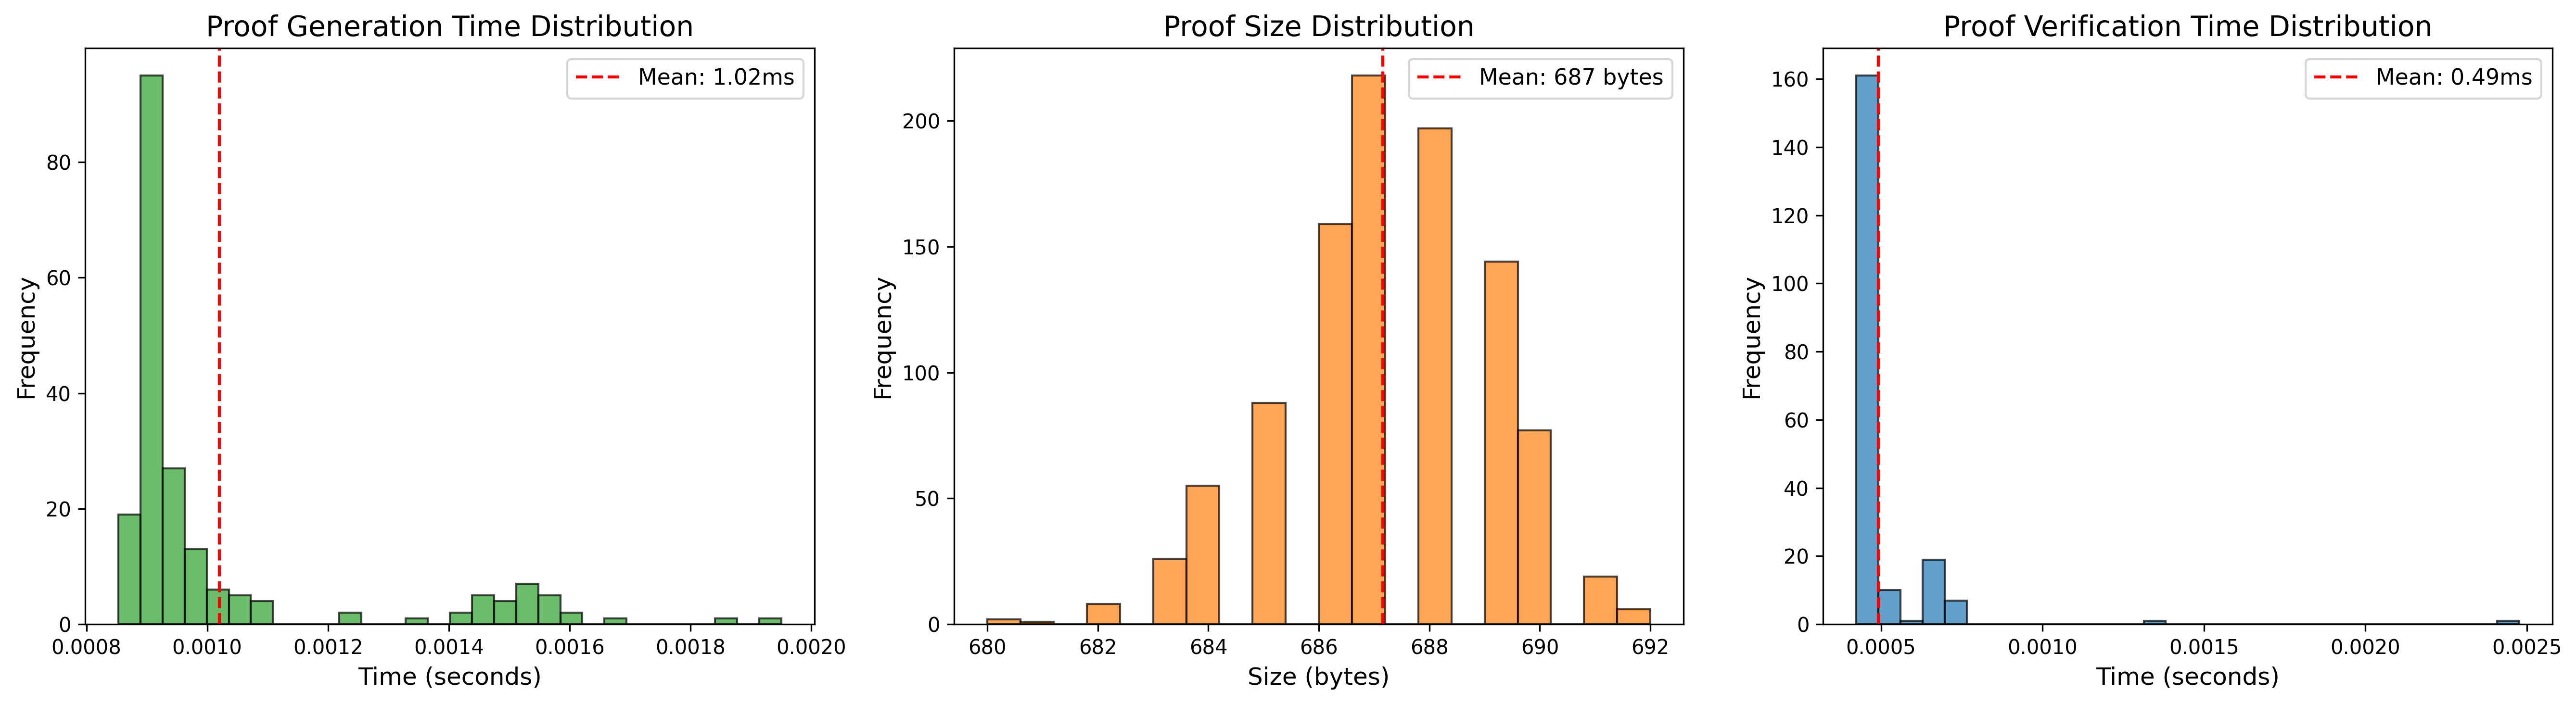


  Blockchain Statistics


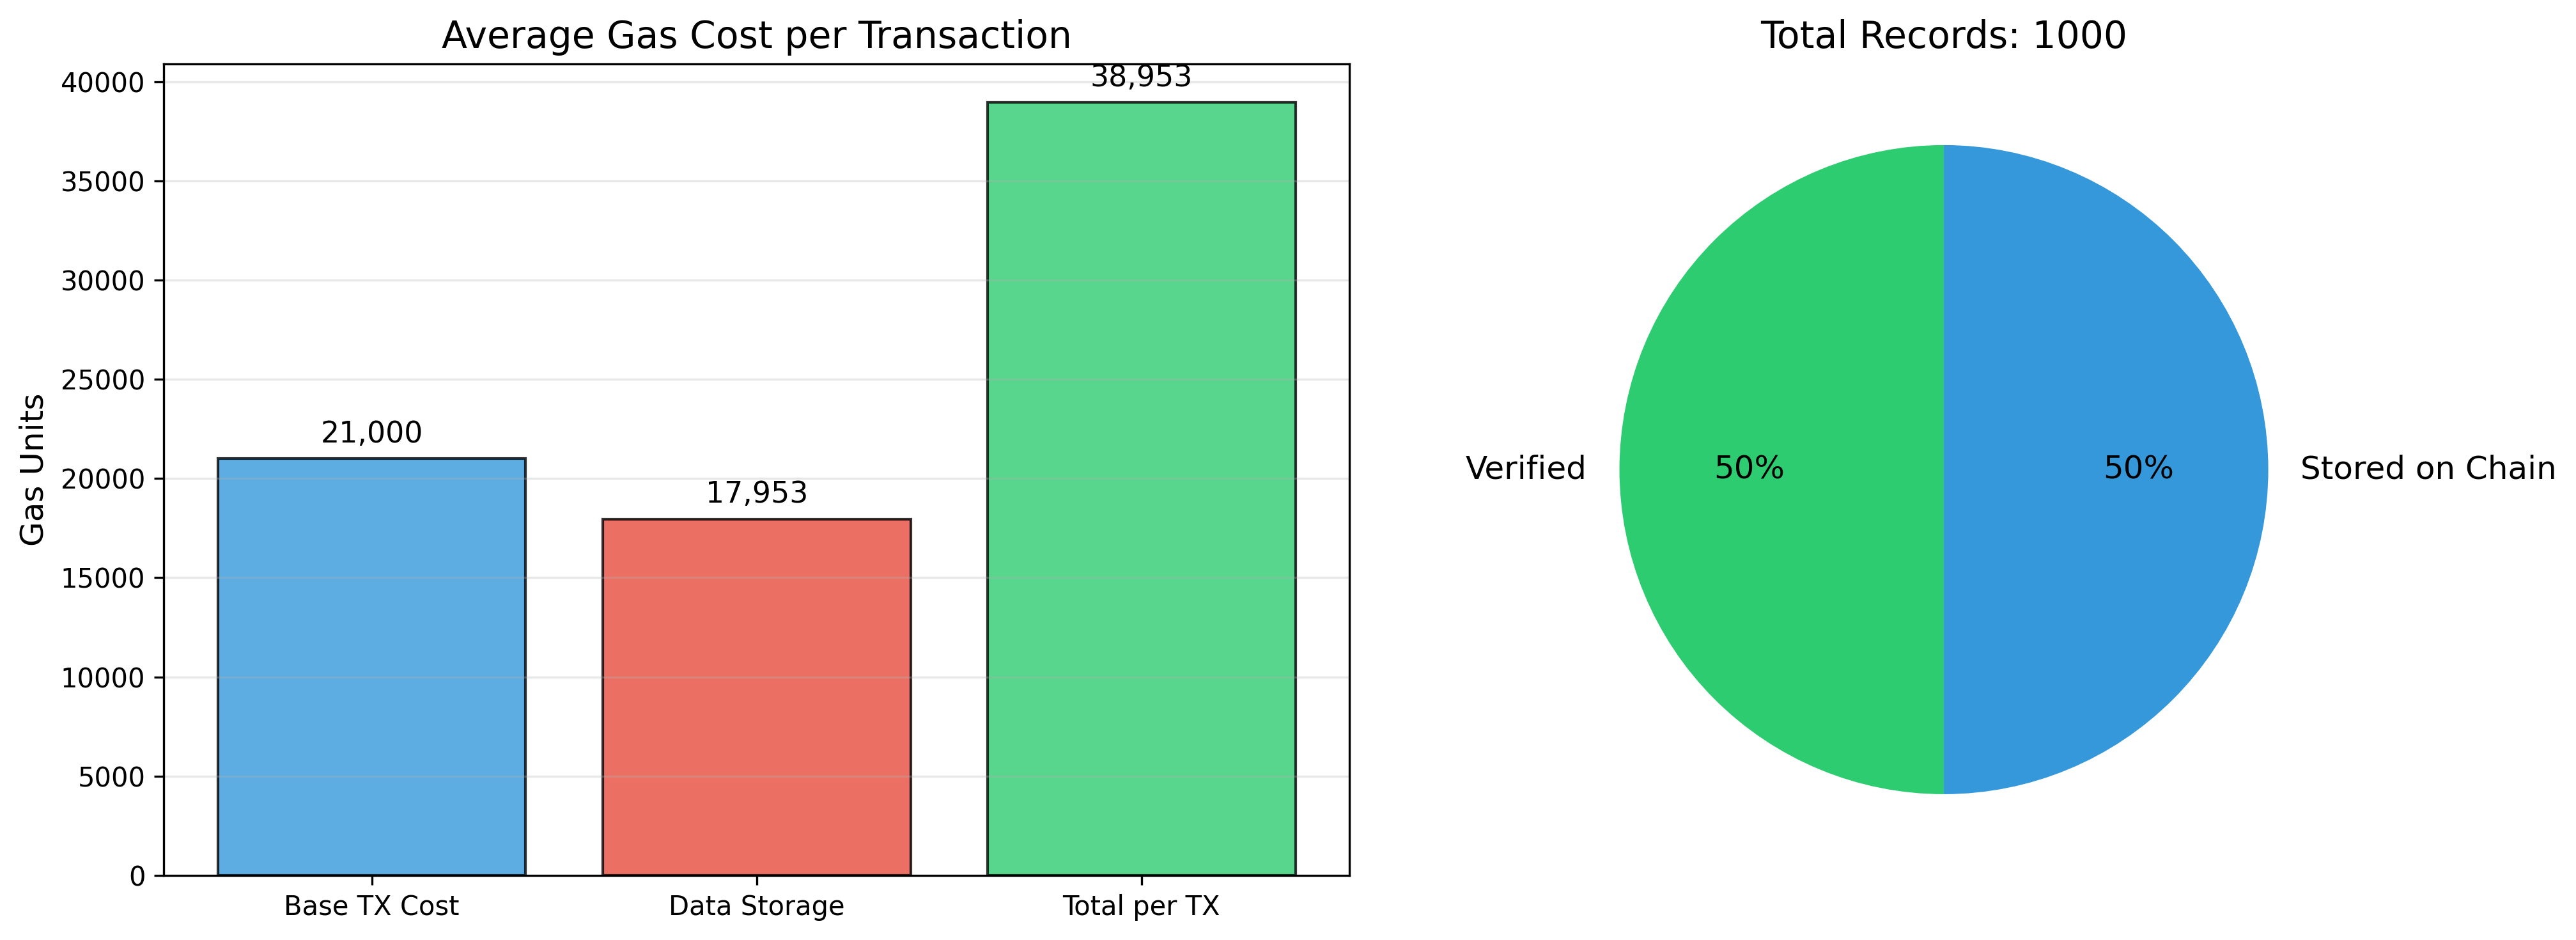


  Pipeline Timing


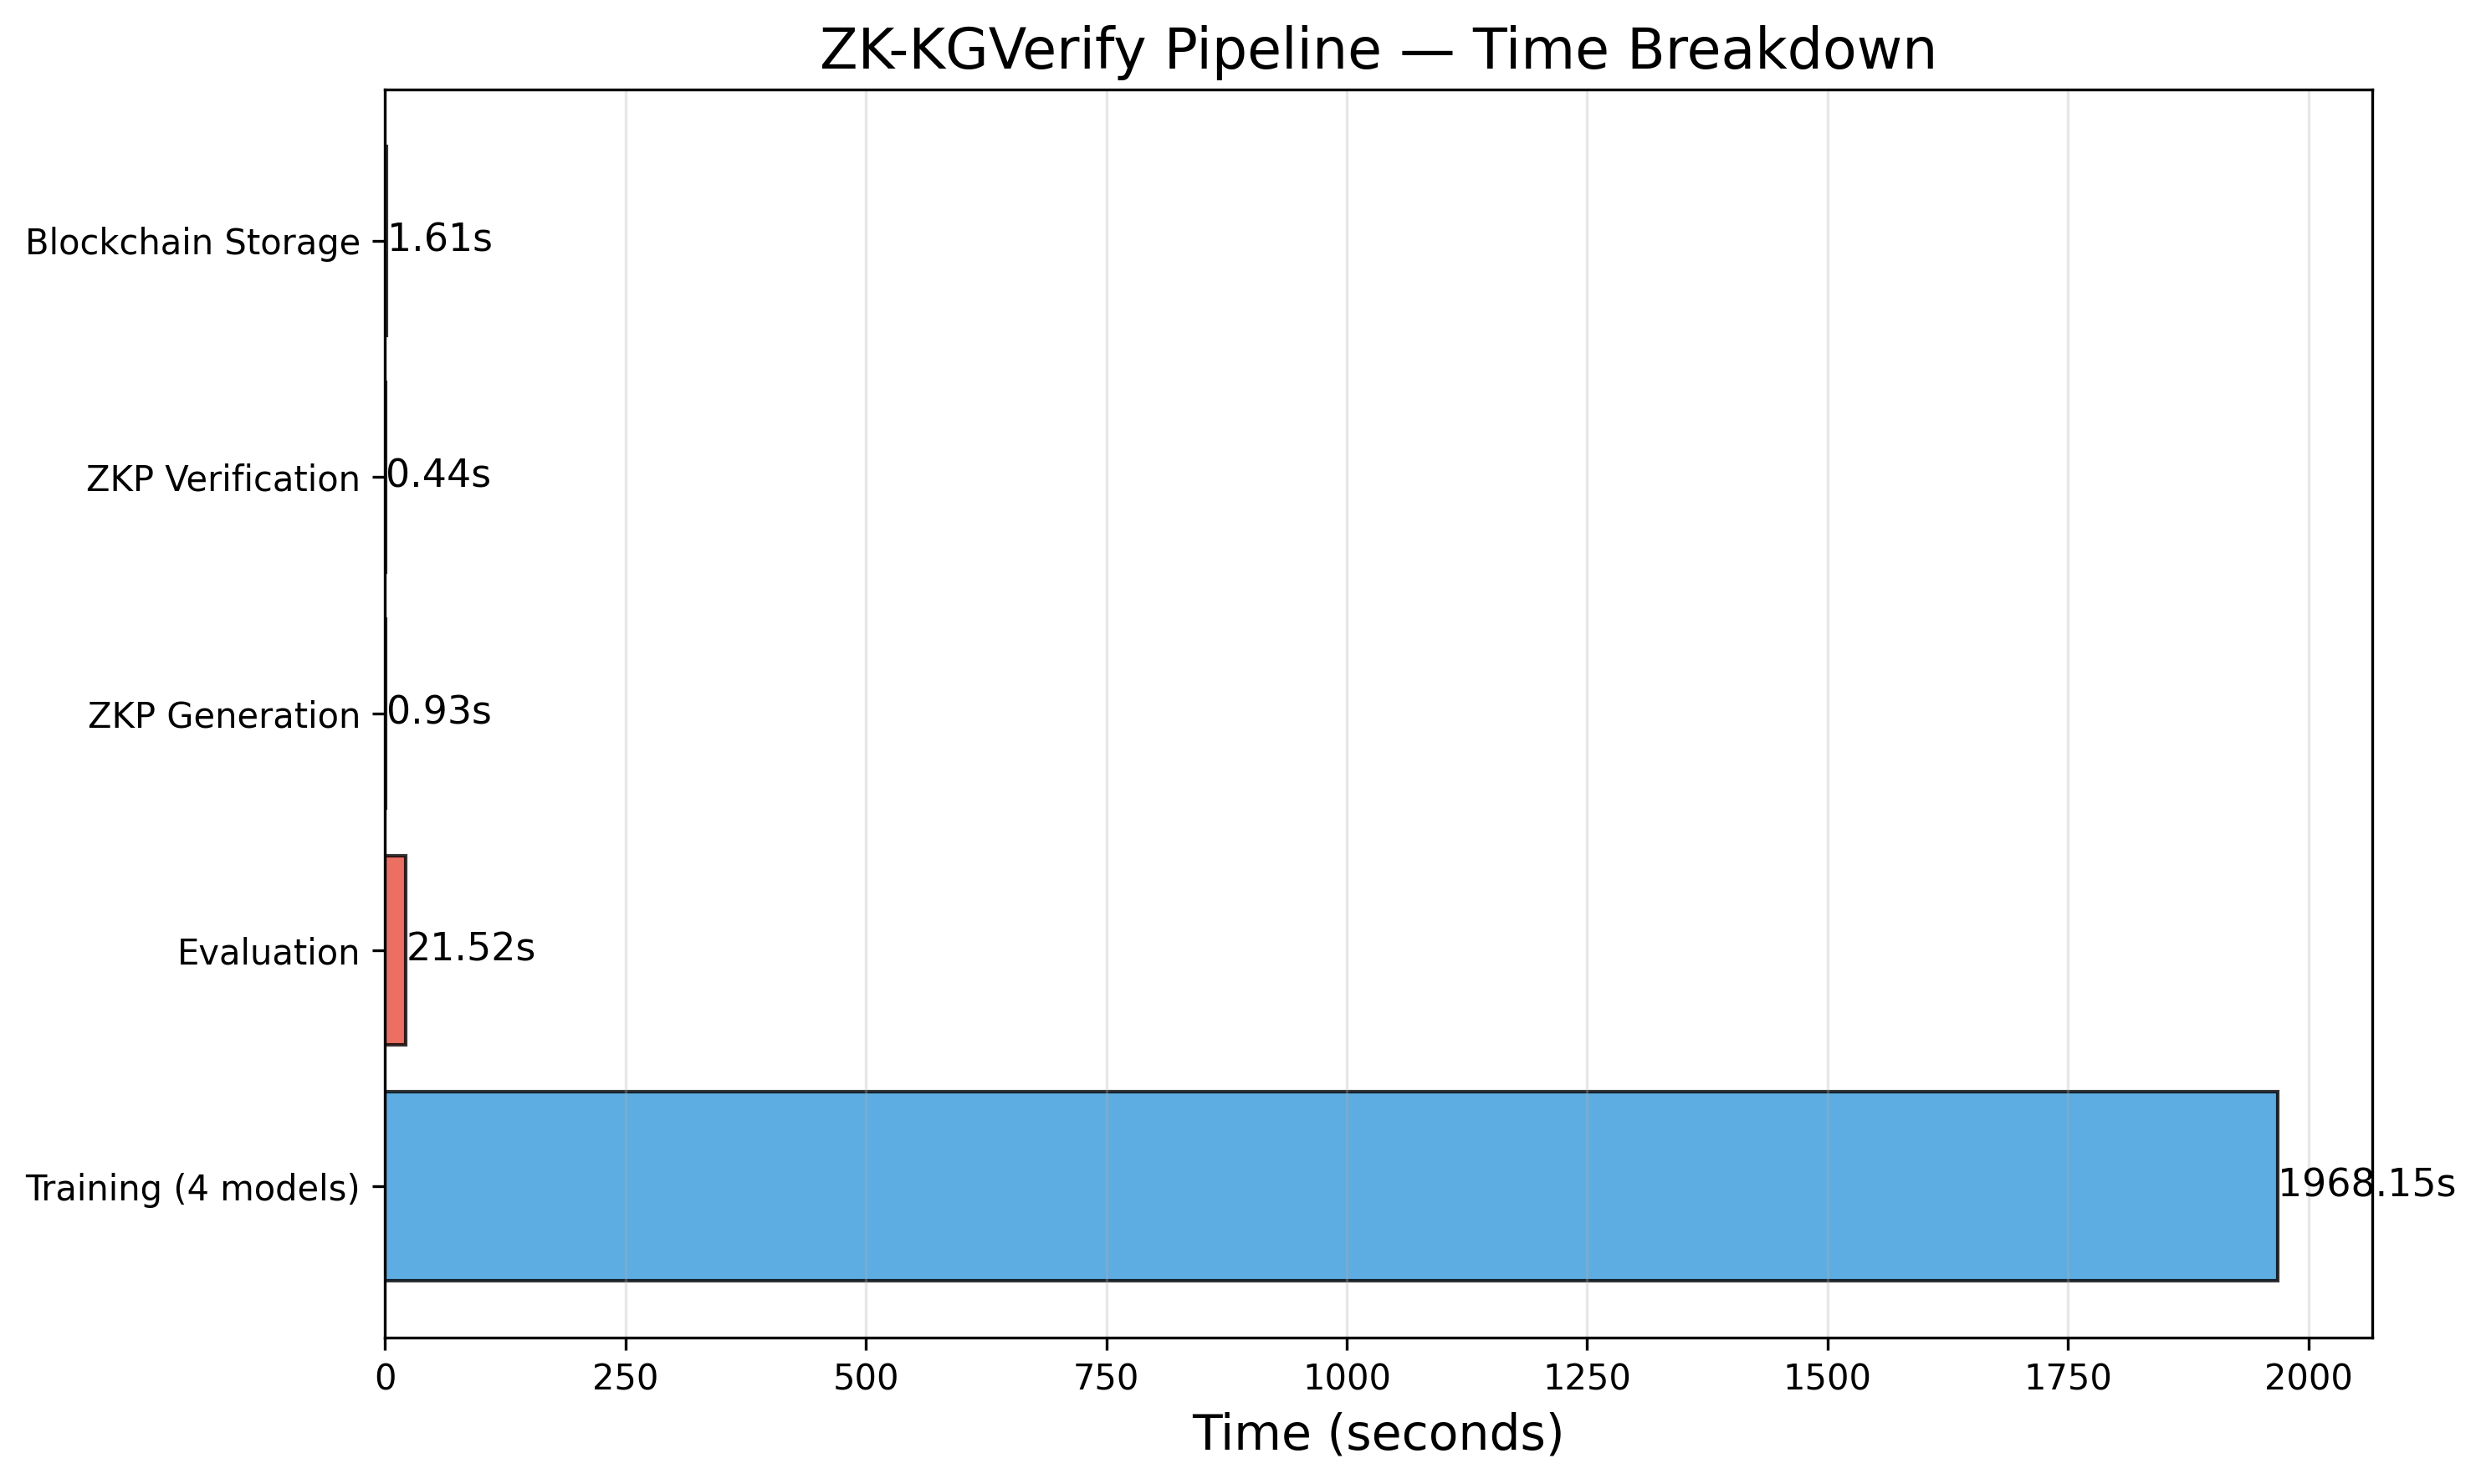

In [26]:
from IPython.display import Image, display

figures = [
    ('Training Loss Curves', 'training_curves.png'),
    ('Link Prediction Metrics', 'metrics_comparison.png'),
    ('ZKP Overhead Analysis', 'zkp_overhead.png'),
    ('Blockchain Statistics', 'blockchain_stats.png'),
    ('Pipeline Timing', 'pipeline_timing.png'),
]

for title, fname in figures:
    fpath = f'./results/{fname}'
    if os.path.exists(fpath):
        print(f"\n{'='*50}")
        print(f"  {title}")
        print(f"{'='*50}")
        display(Image(filename=fpath, width=800))

In [27]:
# Display LaTeX tables
print("\nLaTeX Tables for Paper:")
print("=" * 50)
with open('./results/tables.tex', 'r') as f:
    print(f.read())


LaTeX Tables for Paper:
\begin{table}[h]
\centering
\caption{Link Prediction Results on FB15k-237}
\label{tab:link_prediction}
\begin{tabular}{lcccc}
\hline
Model & MRR & Hits@1 & Hits@3 & Hits@10 \\
\hline
TransE & 0.1760 & 0.0980 & 0.1900 & 0.3340 \\
RotatE & 0.2719 & 0.1780 & 0.3220 & 0.4480 \\
CompGCN & 0.4086 & 0.3140 & 0.4400 & 0.6220 \\
\hline
\end{tabular}
\end{table}

\begin{table}[h]
\centering
\caption{ZKP Overhead Analysis}
\label{tab:zkp_overhead}
\begin{tabular}{lc}
\hline
Metric & Value \\
\hline
Avg. Proof Generation Time & 0.93 ms \\
Avg. Proof Verification Time & 0.44 ms \\
Avg. Proof Size & 687 bytes \\
Verification Rate & 0.0\% \\
\hline
\end{tabular}
\end{table}

\begin{table}[h]
\centering
\caption{Blockchain Storage Costs}
\label{tab:blockchain}
\begin{tabular}{lc}
\hline
Metric & Value \\
\hline
Total Transactions & 1000 \\
Total Gas Used & 38,952,748 \\
Avg. Gas per TX & 38,953 \\
Avg. Mining Time & 15.89 ms \\
Chain Valid & True \\
\hline
\end{tabular}
\end{t

In [28]:
# Final summary
print("\n" + "=" * 70)
print("  ZK-KGVerify — EXPERIMENT COMPLETE")
print("=" * 70)
print(f"\n  Best model: {best_model_name} (MRR={all_metrics[best_model_name]['MRR']:.4f})")
print(f"  ZKP overhead: {zkp_full_stats['avg_gen_time']*1000:.2f}ms per proof")
print(f"  Tamper detection: {zkp_full_stats['tamper_detection_rate']*100:.1f}%")
print(f"  Blockchain cost: {bc_stats['avg_gas_per_tx']:,.0f} gas/tx")
print(f"\n  All results saved in ./results/")
print("=" * 70)


  ZK-KGVerify — EXPERIMENT COMPLETE

  Best model: CompGCN (MRR=0.4086)
  ZKP overhead: 0.93ms per proof
  Tamper detection: 100.0%
  Blockchain cost: 38,953 gas/tx

  All results saved in ./results/
